In [1]:
!pip install transformers torch matplotlib seaborn bertviz

  Using cached transformers-5.6.2-py3-none-any.whl.metadata (33 kB)
  Using cached torch-2.11.0-cp313-cp313-win_amd64.whl.metadata (29 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached bertviz-1.4.1-py3-none-any.whl.metadata (19 kB)
  Using cached huggingface_hub-1.12.0-py3-none-any.whl.metadata (14 kB)
  Using cached pyyaml-6.0.3-cp313-cp313-win_amd64.whl.metadata (2.4 kB)
  Using cached regex-2026.4.4-cp313-cp313-win_amd64.whl.metadata (41 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached typer-0.25.0-py3-none-any.whl.metadata (15 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached fsspec-2026.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached typing_extensions-4.15.0-py3-none-


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


c:\Users\andre\Documents\Otus\ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Используемое устройство: cpu


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6034.40it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 35821.06it/s]
[transformers] BertModel LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Stat

Модели успешно загружены.
Токены BERT: ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', 'because', 'it', 'was', 'tired', '.', '[SEP]']
Токены GPT-2: ['The', 'Ġcat', 'Ġsat', 'Ġon', 'Ġthe', 'Ġmat', 'Ġbecause', 'Ġit', 'Ġwas', 'Ġtired', '.']
Токены RuBERT: ['[CLS]', 'Кошка', 'села', 'на', 'ков', '##рик', ',', 'потому', 'что', 'она', 'устал', '##а', '.', '[SEP]']
Количество слоёв BERT: 12
Количество слоёв GPT-2: 12
Количество слоёв RuBERT: 12
Форма attention одной головы BERT: torch.Size([1, 12, 13, 13])


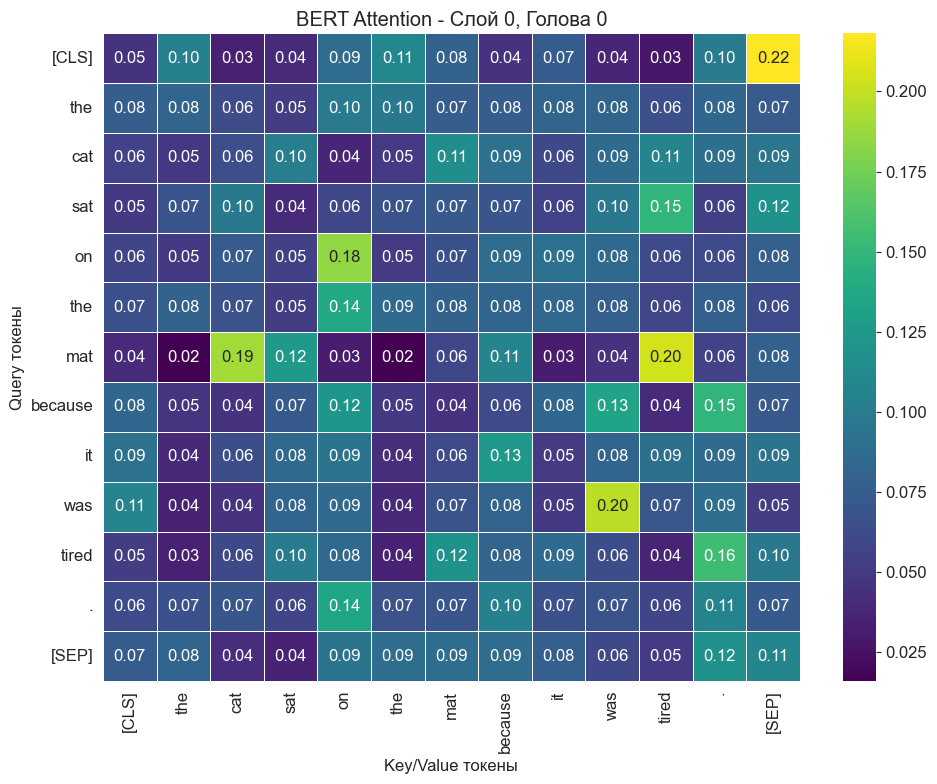

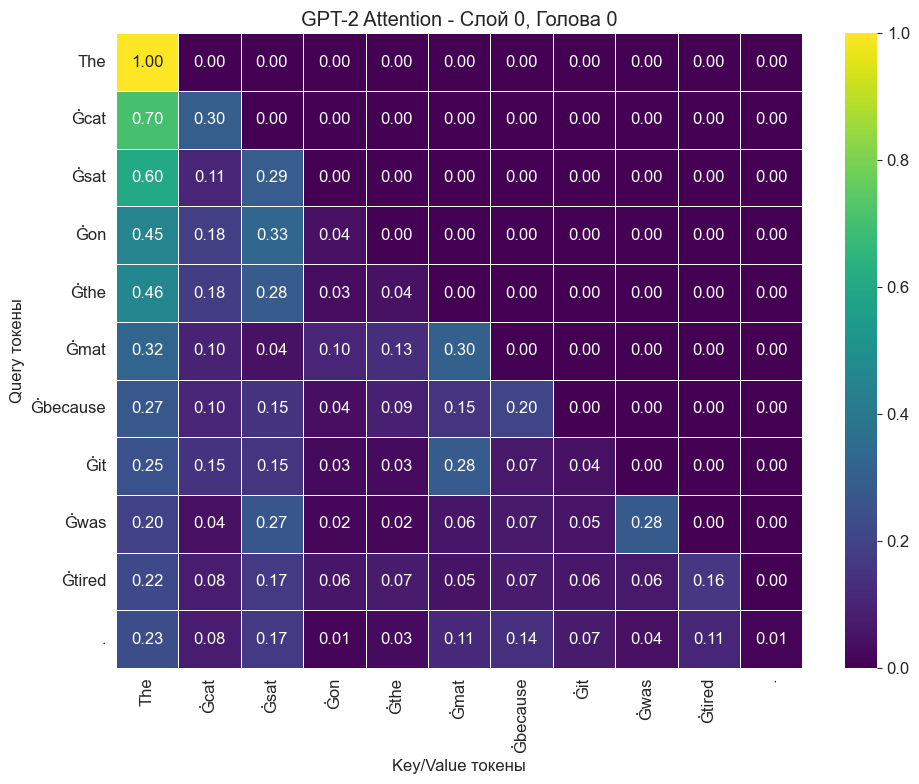

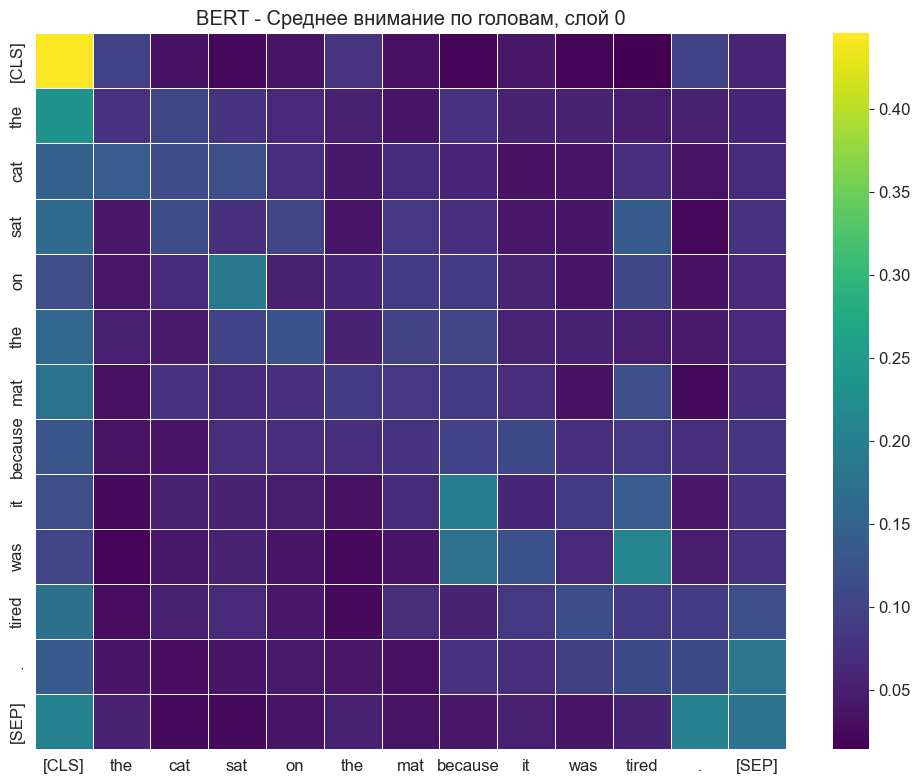

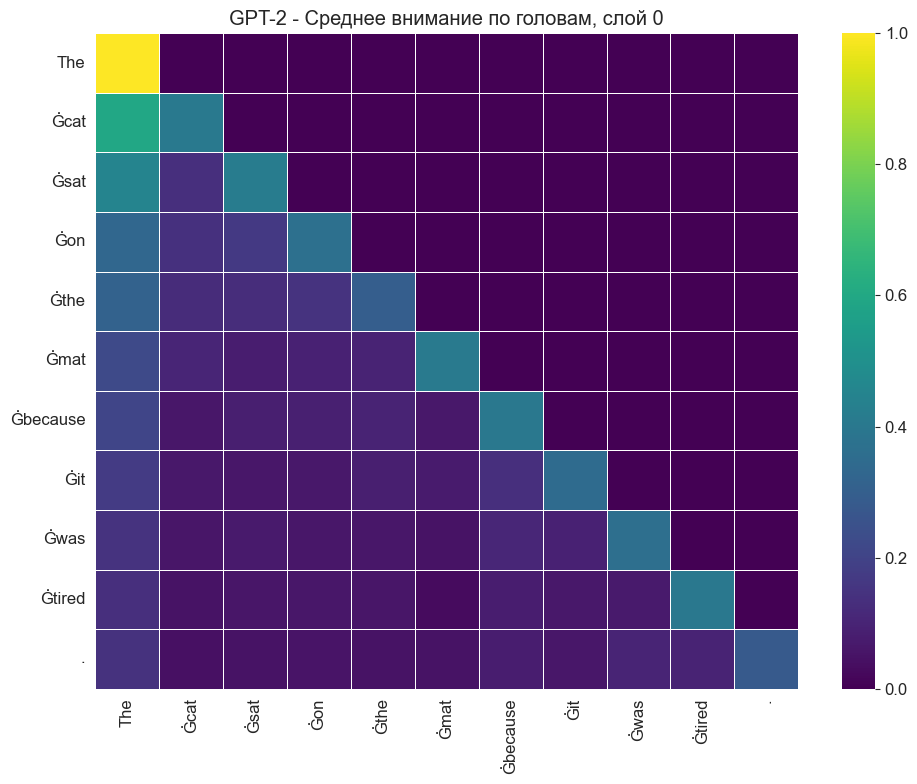

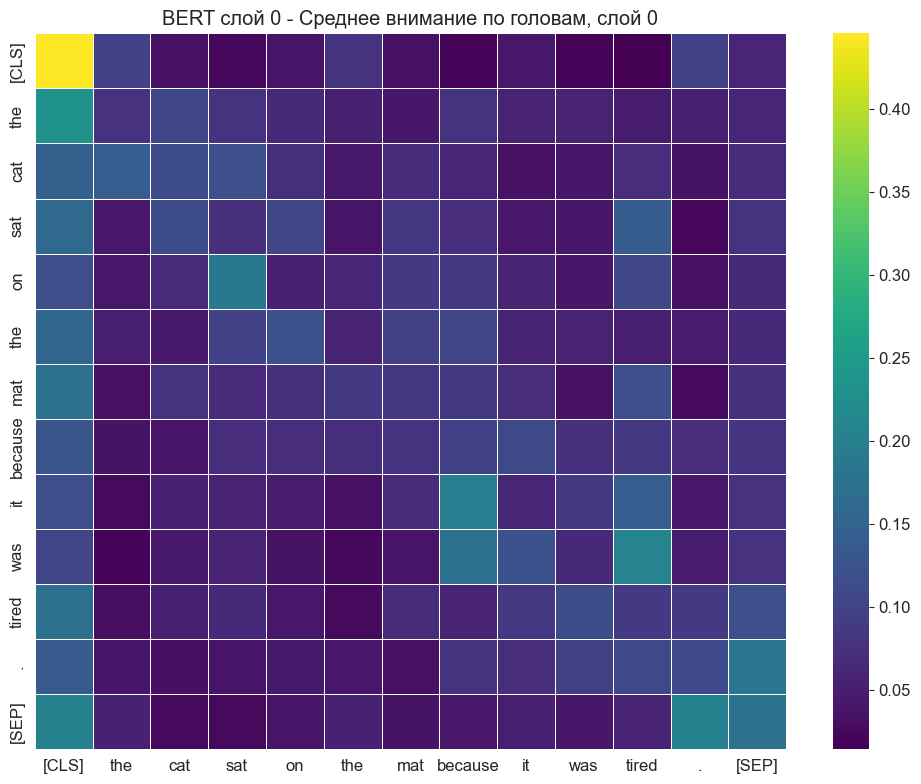

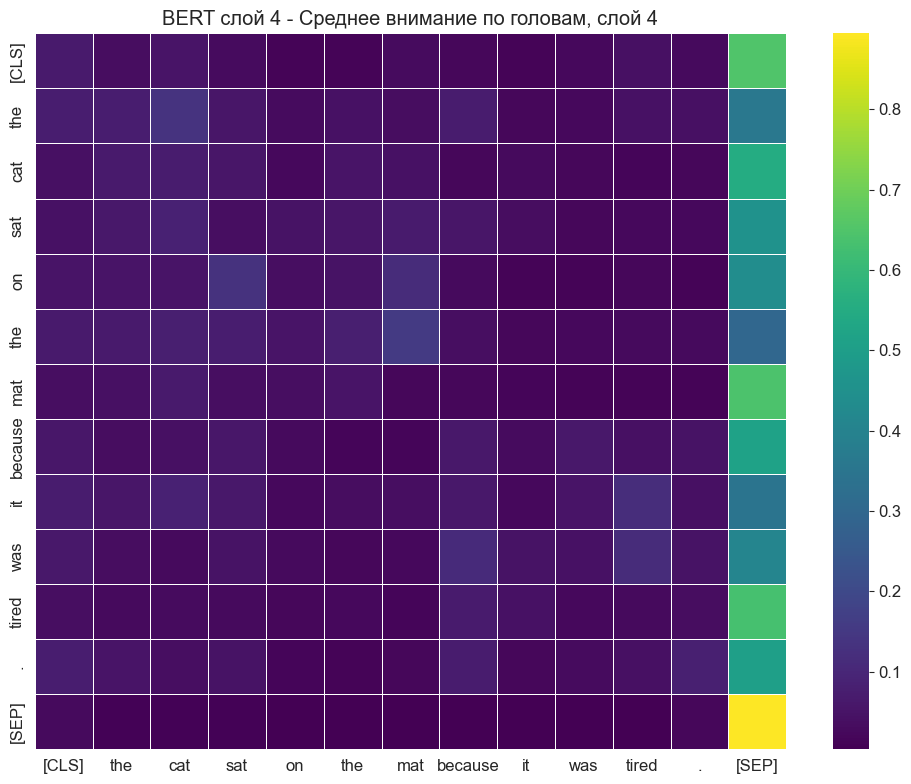

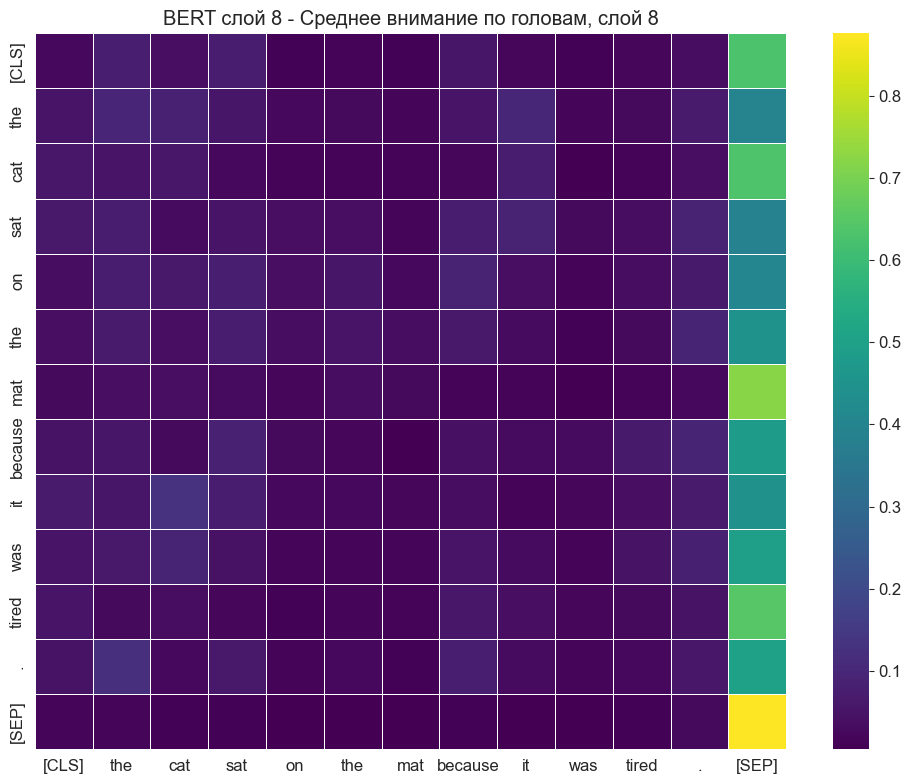

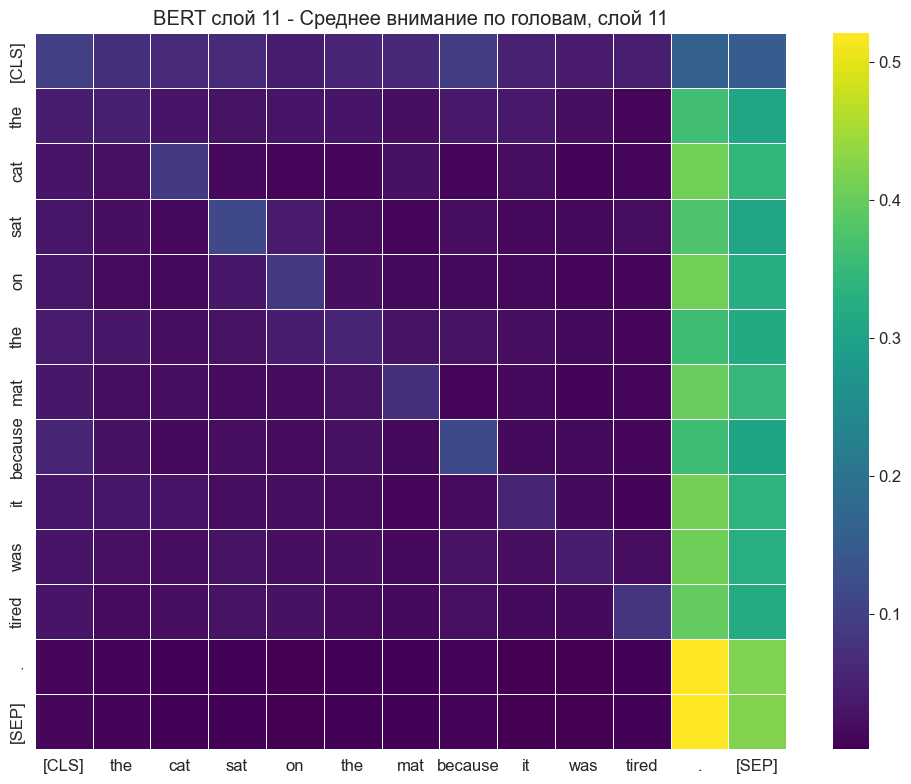

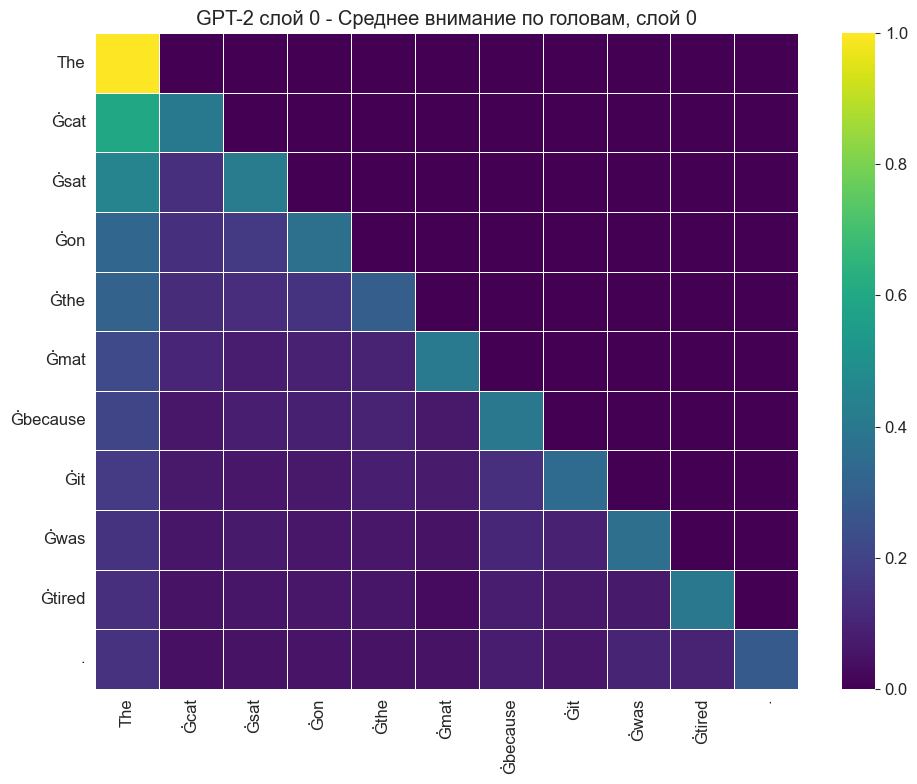

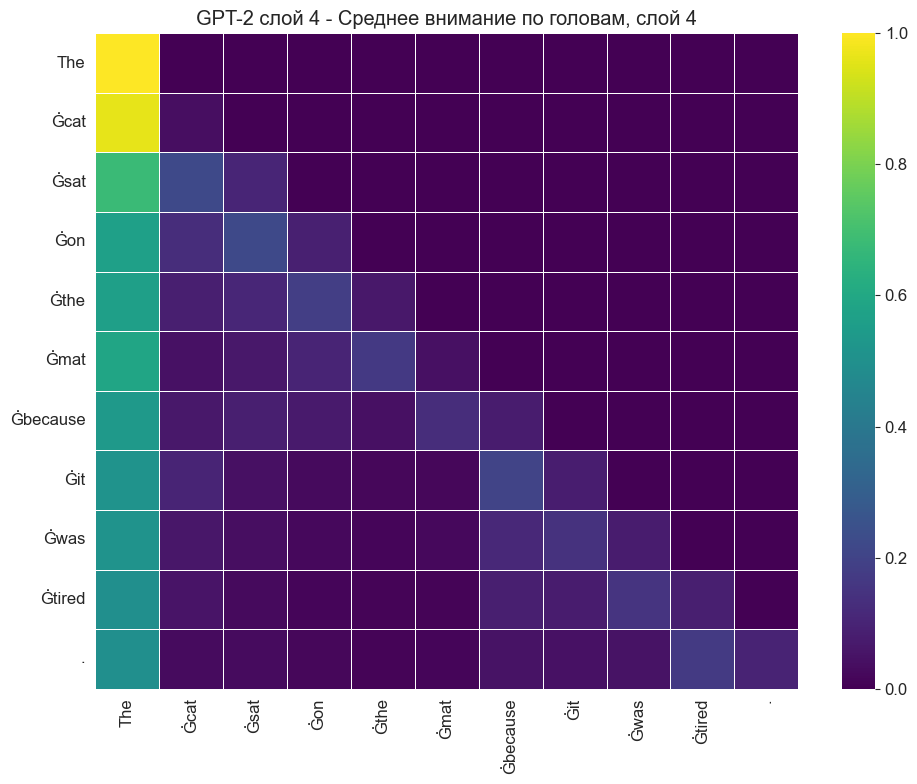

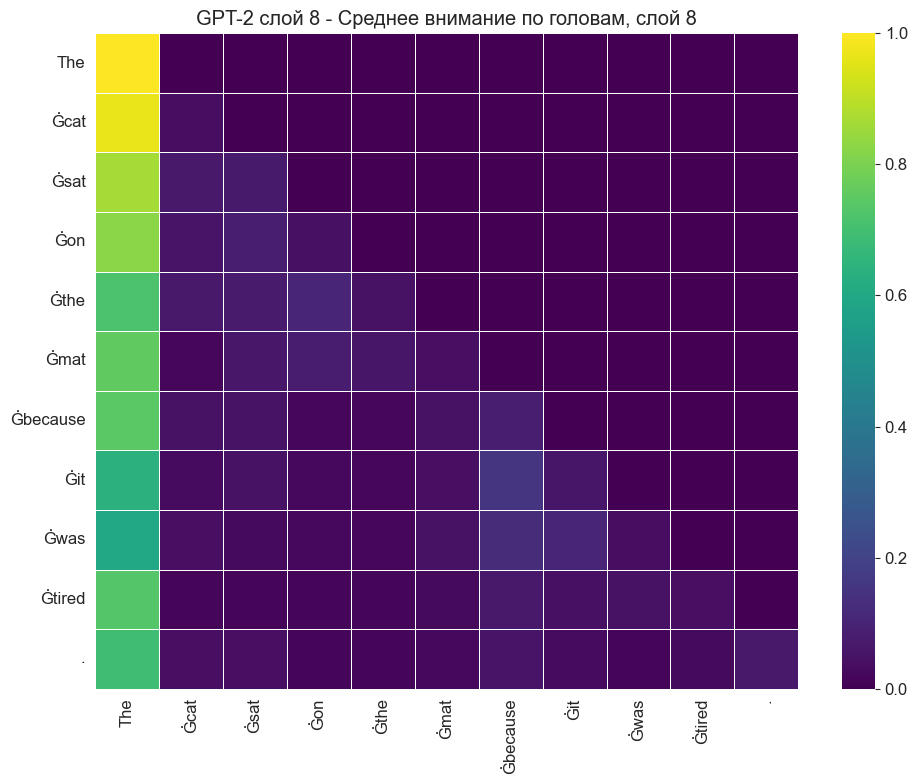

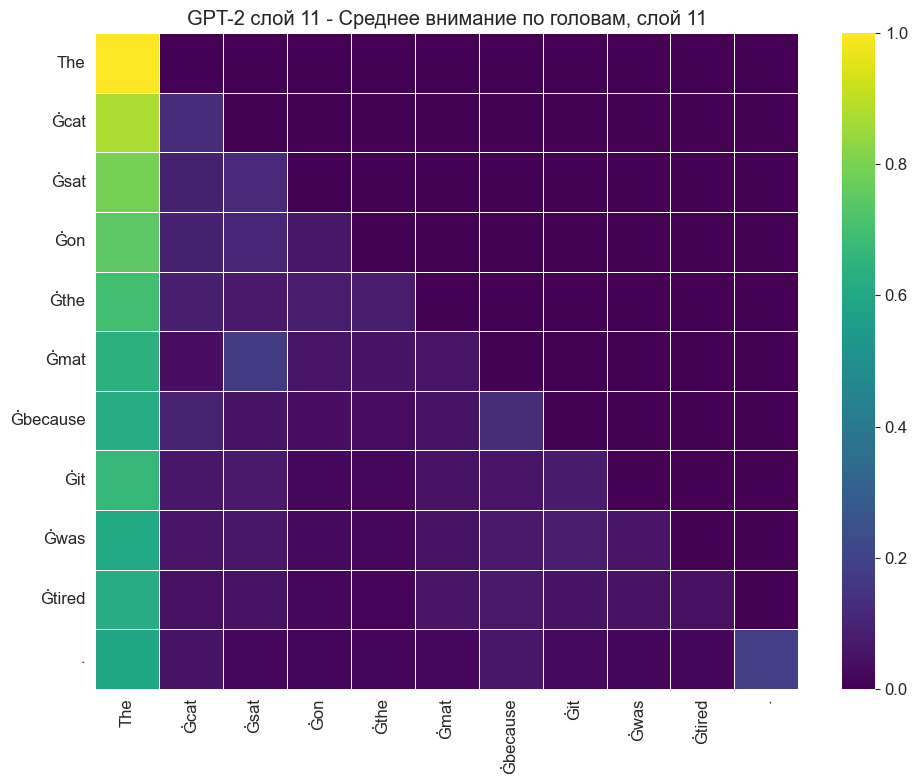

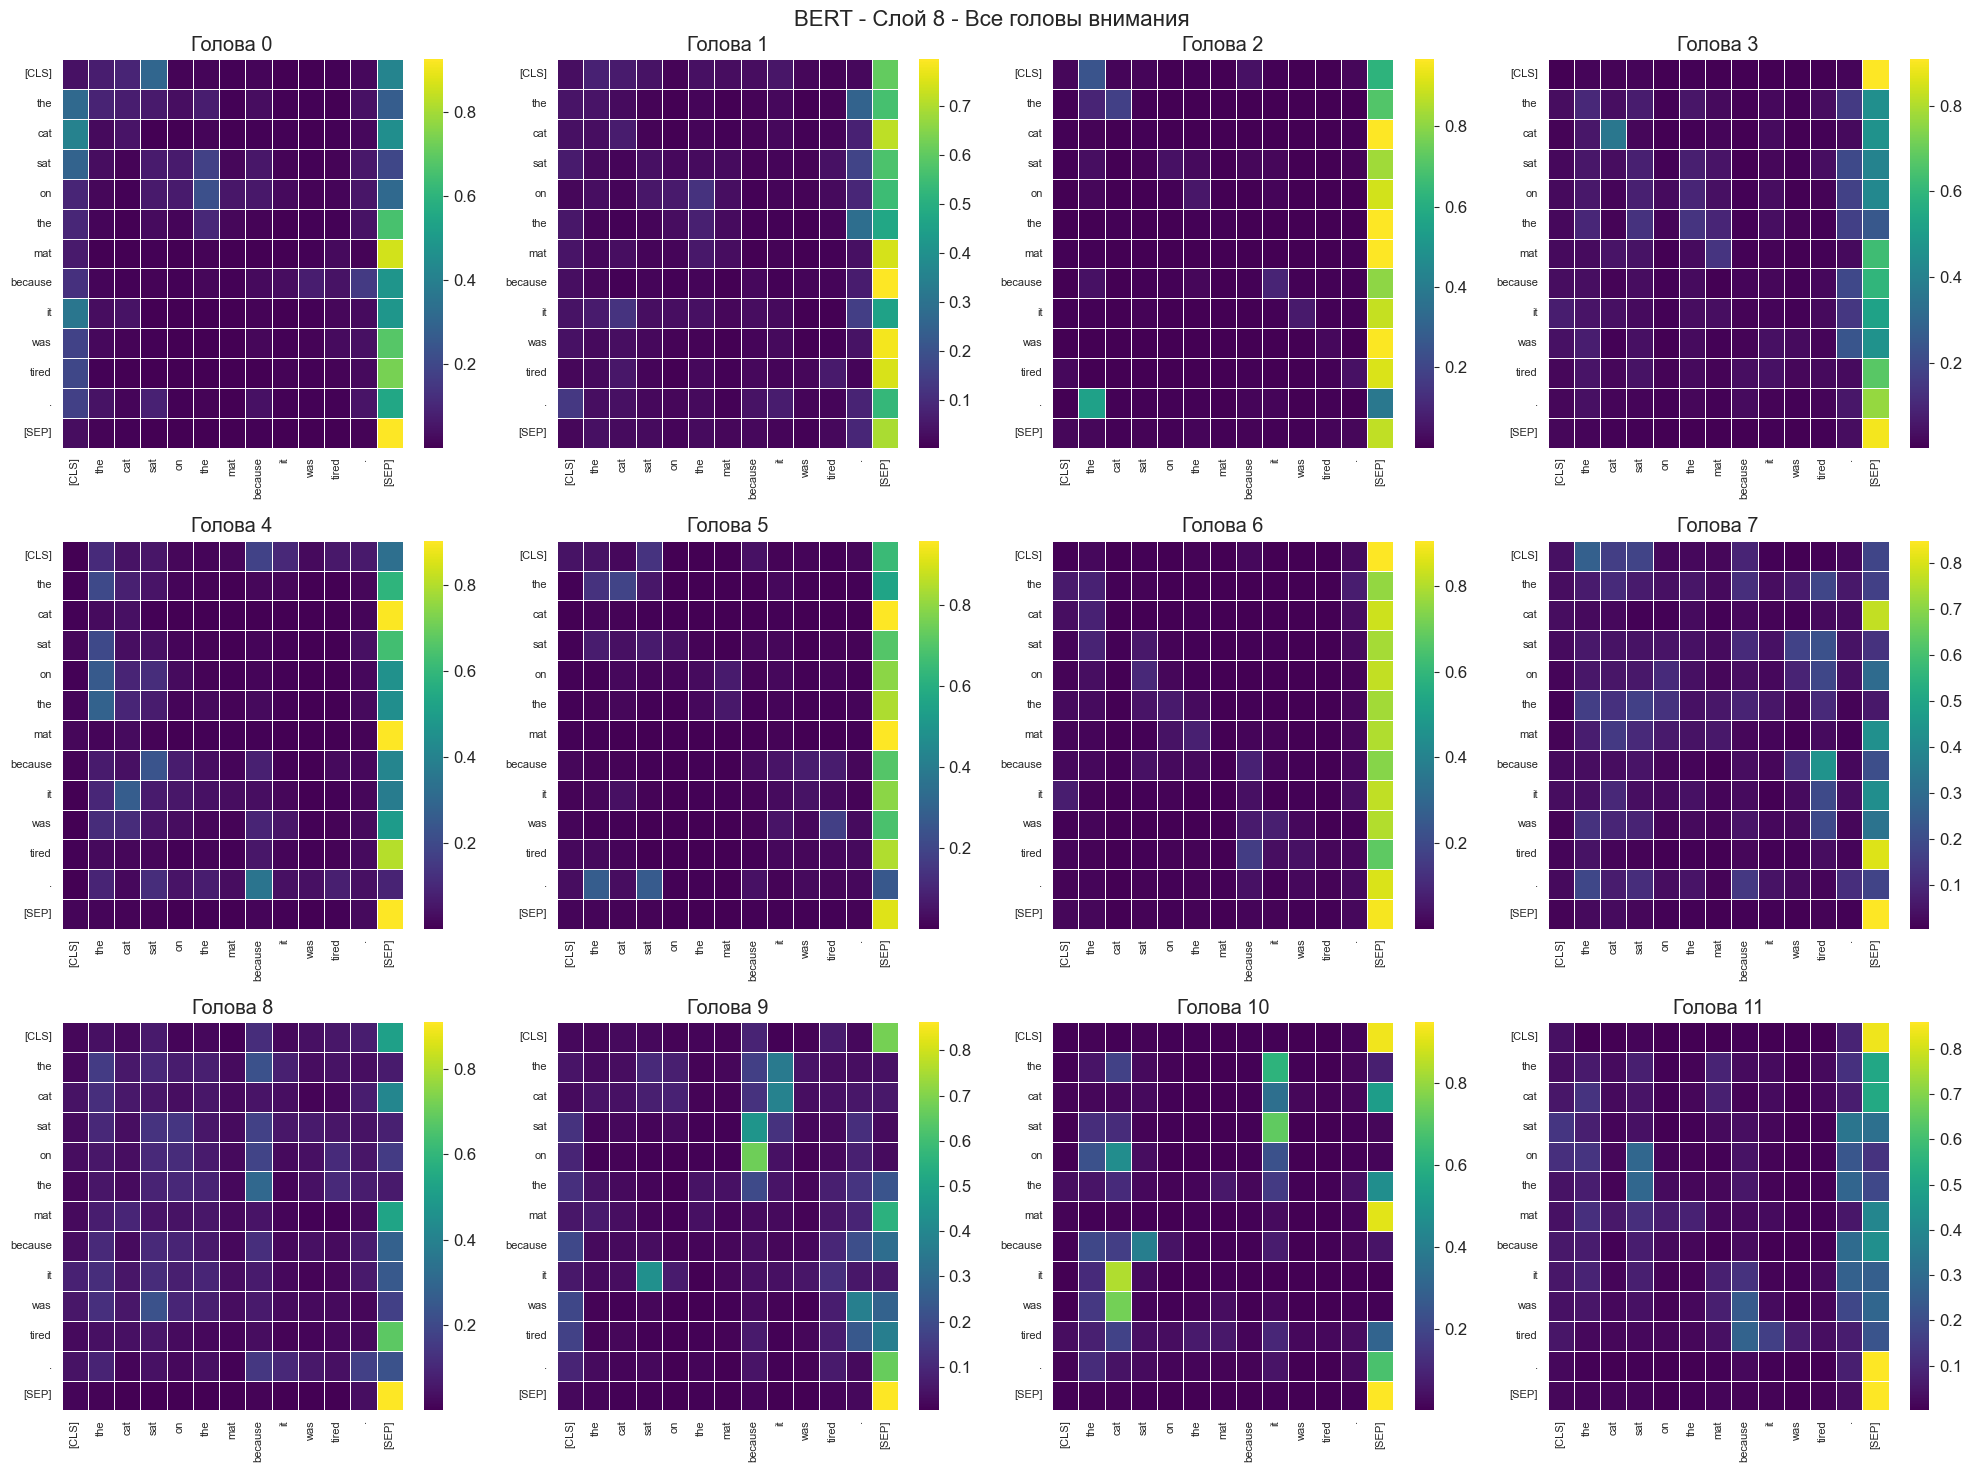

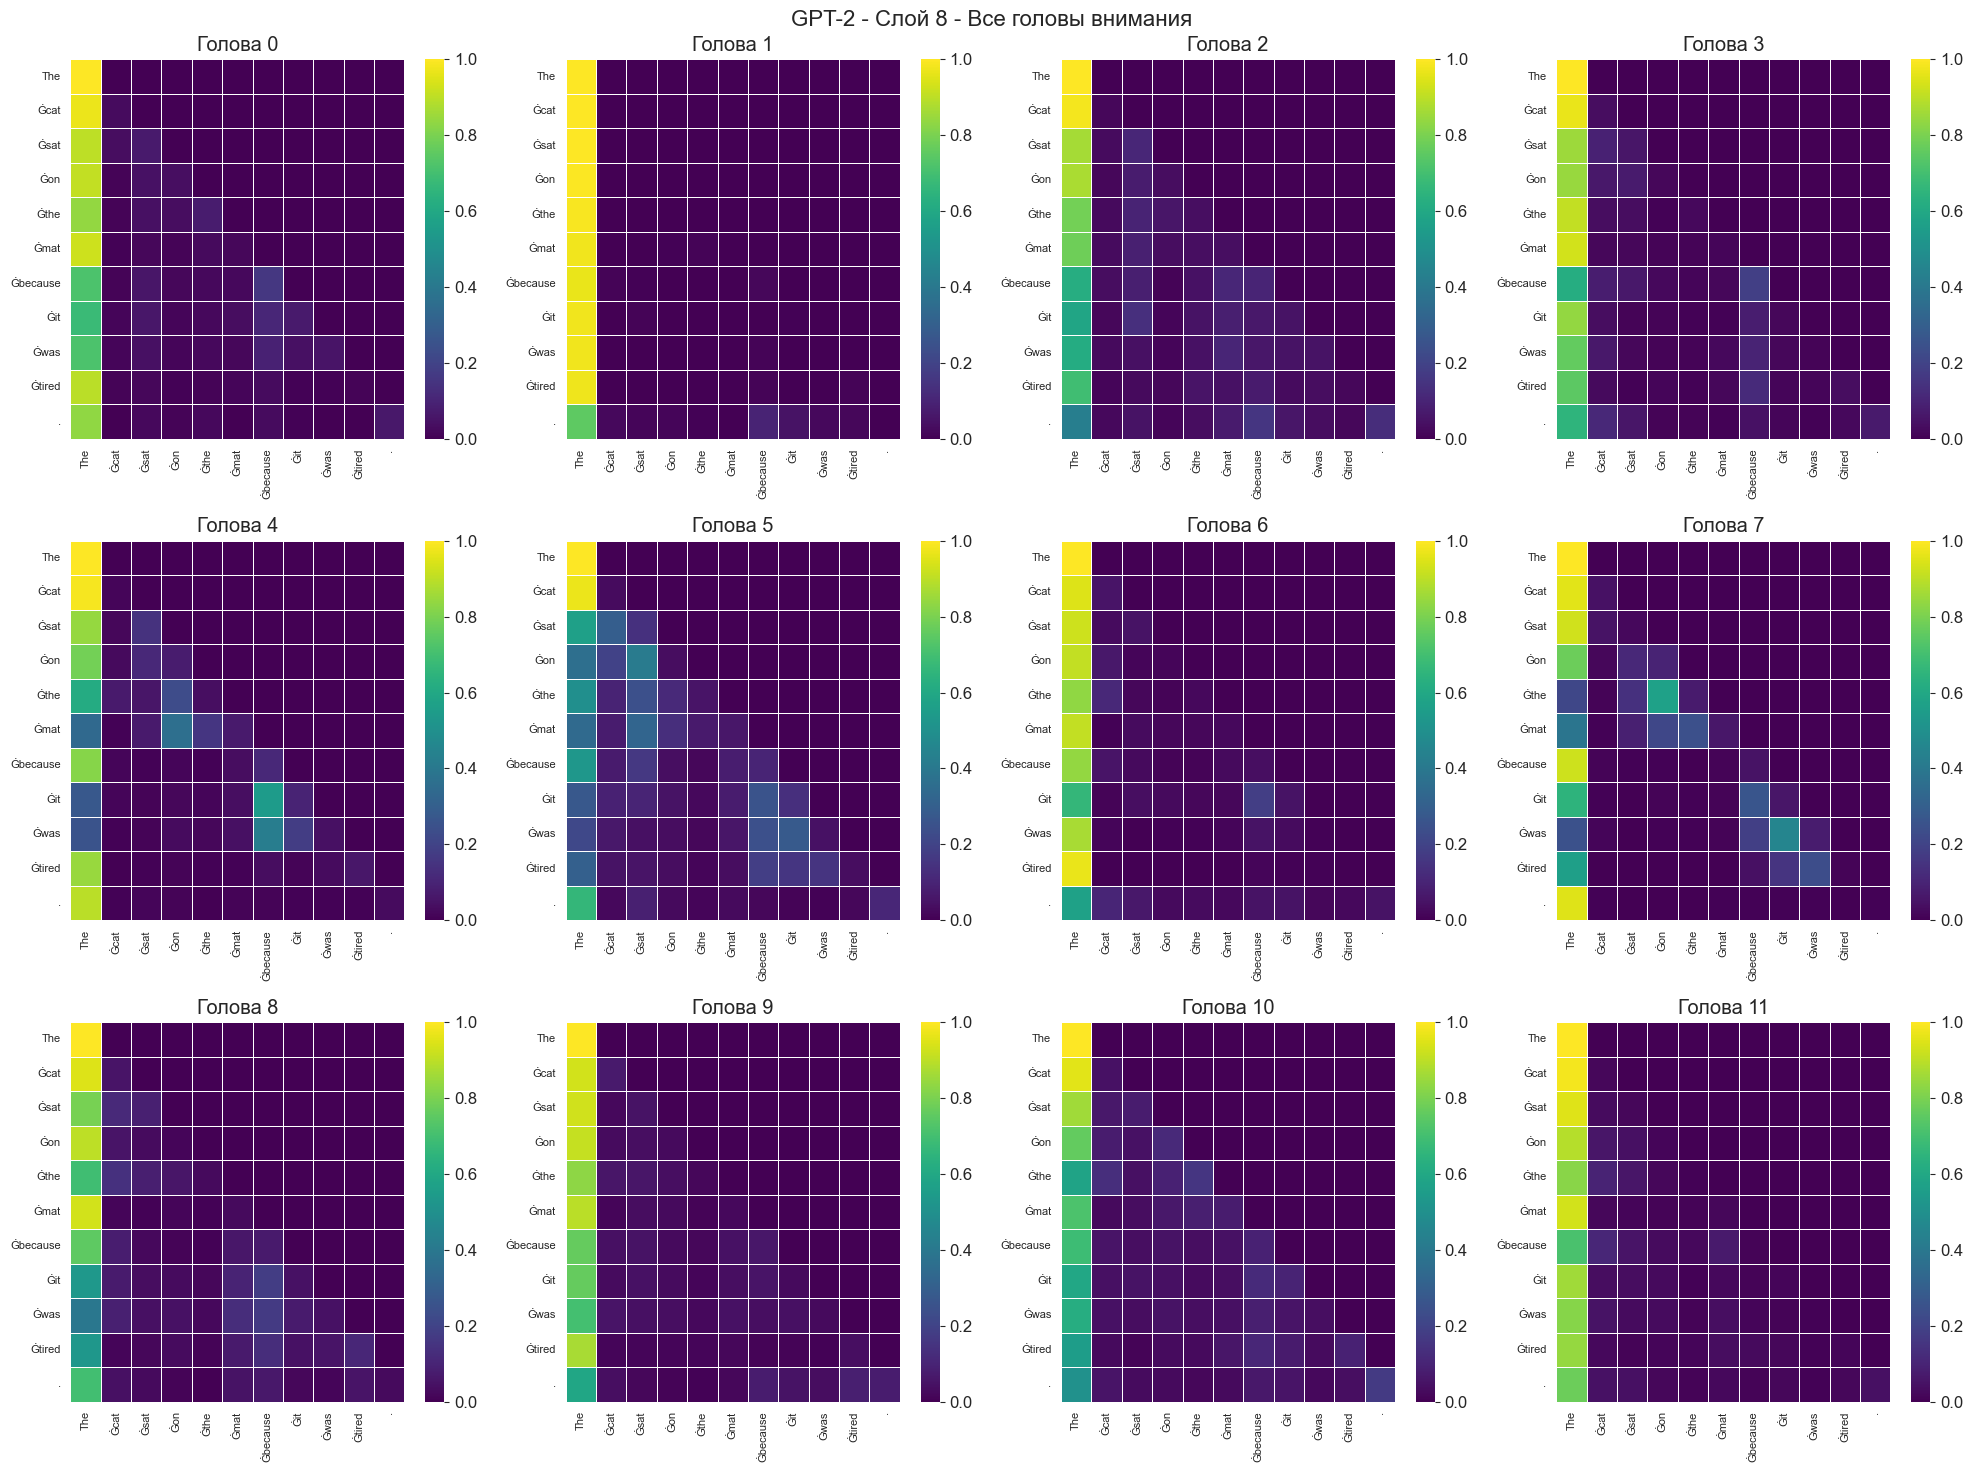

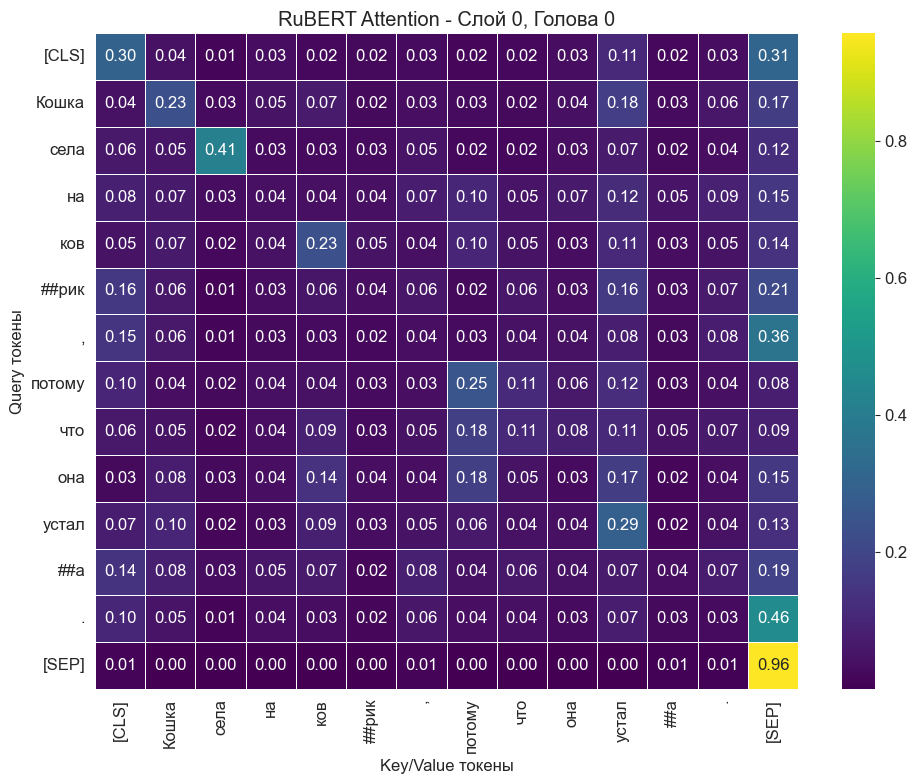

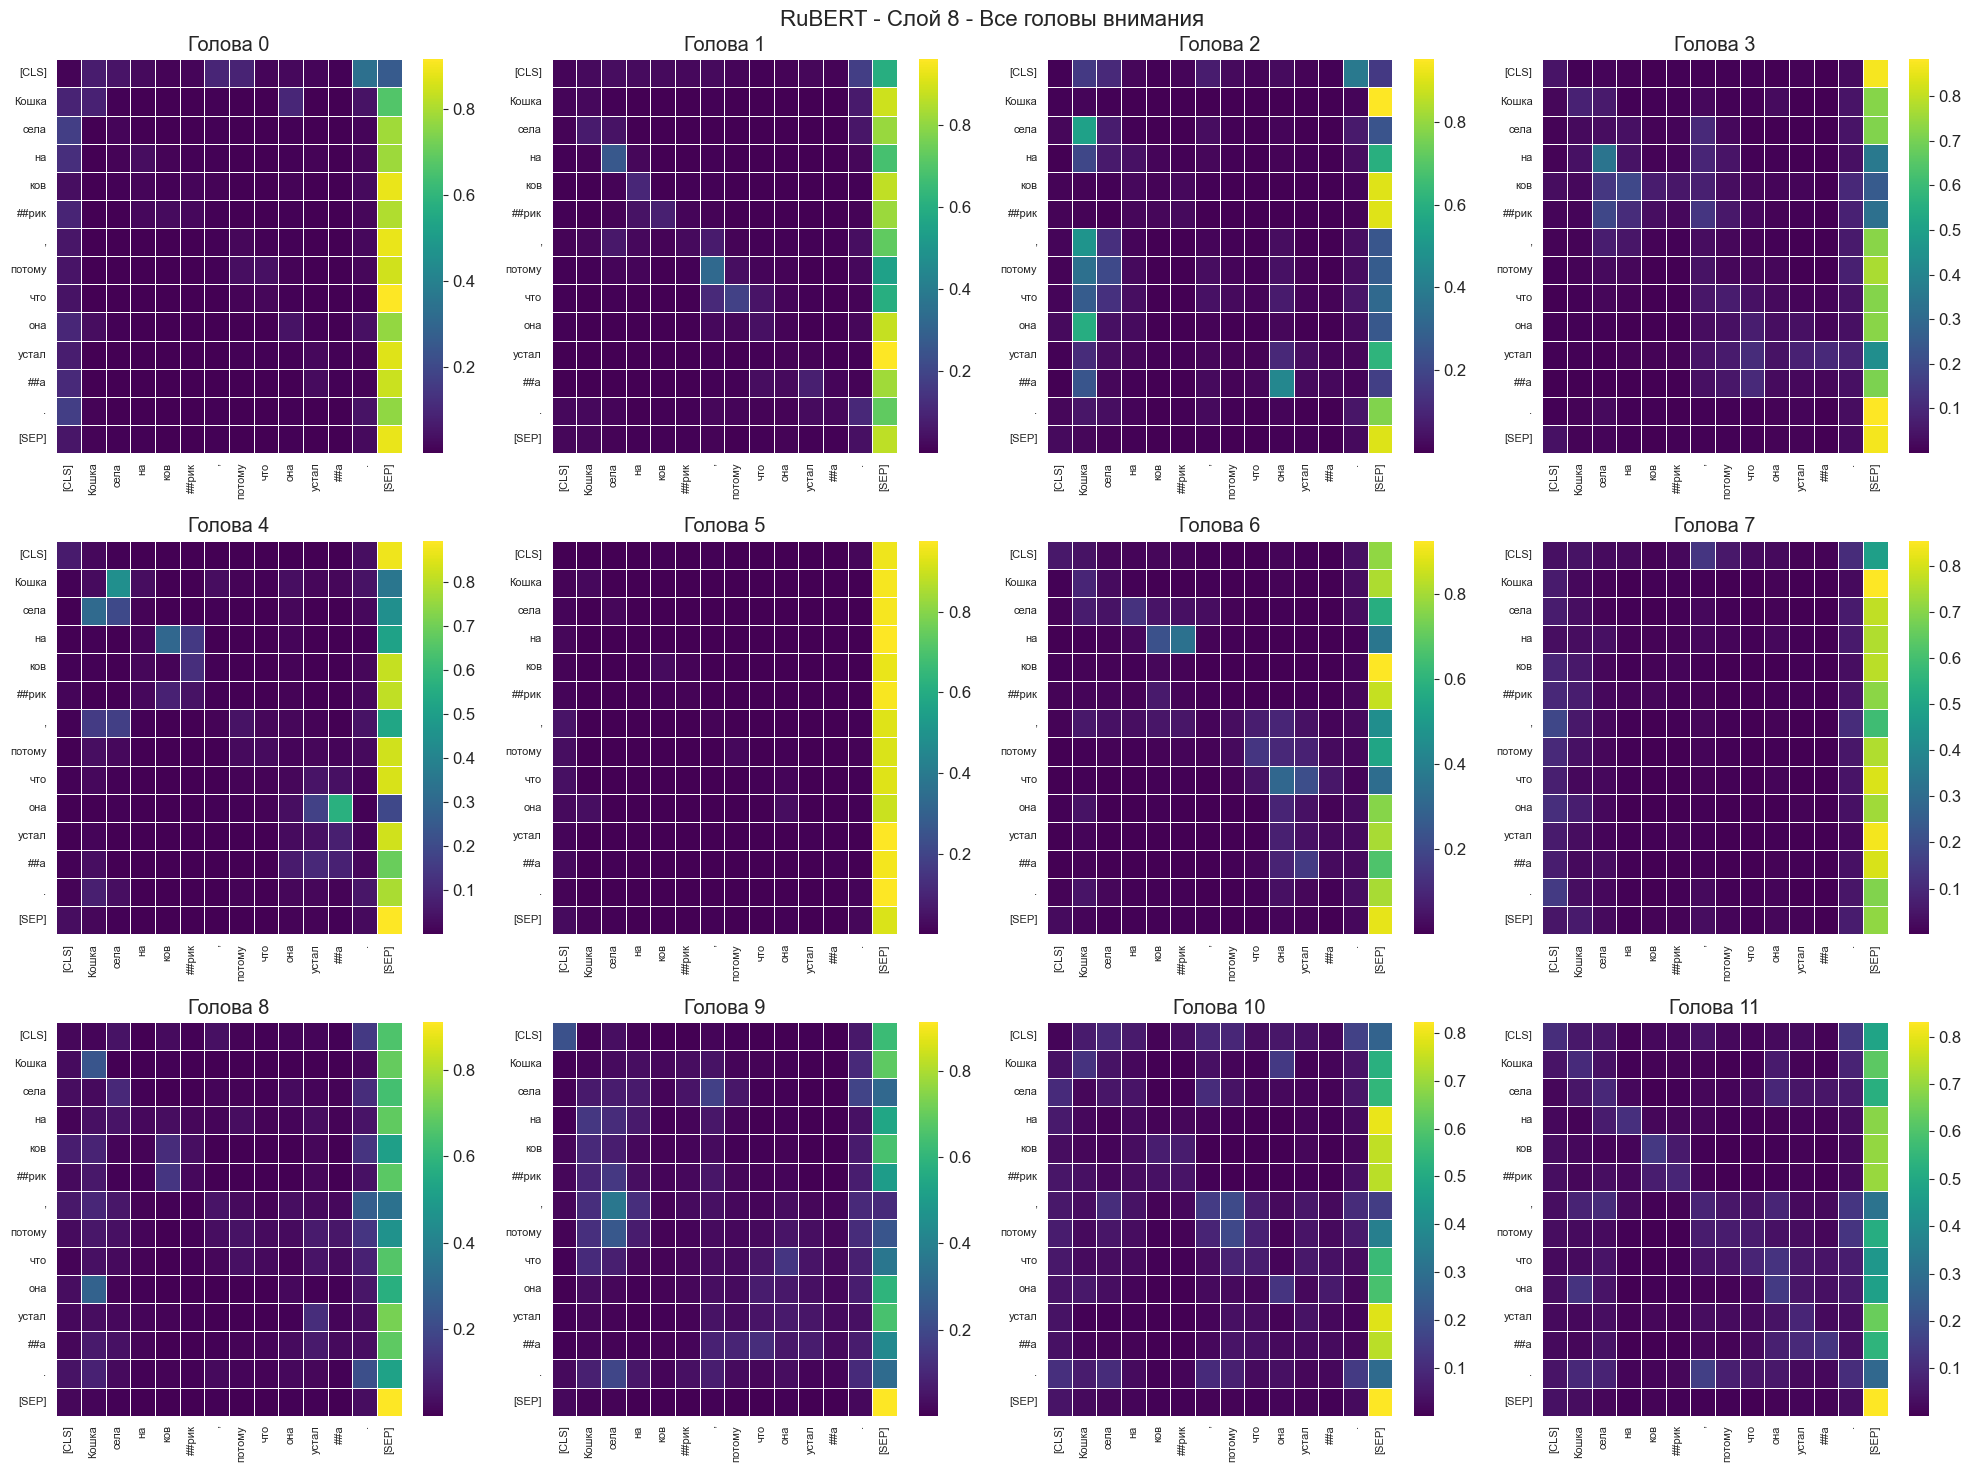

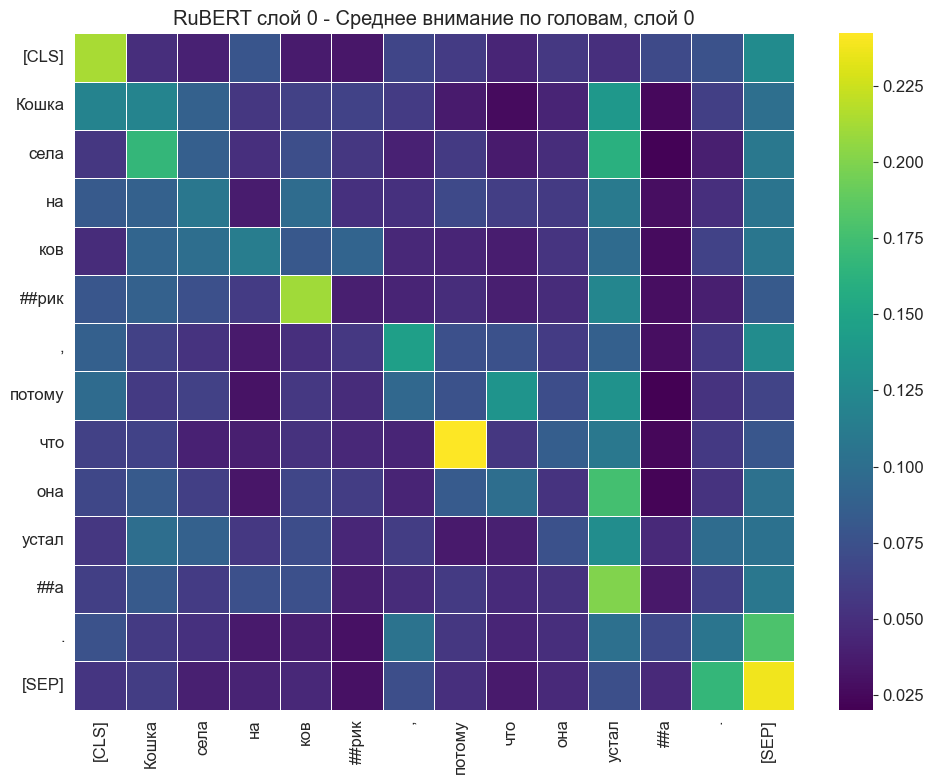

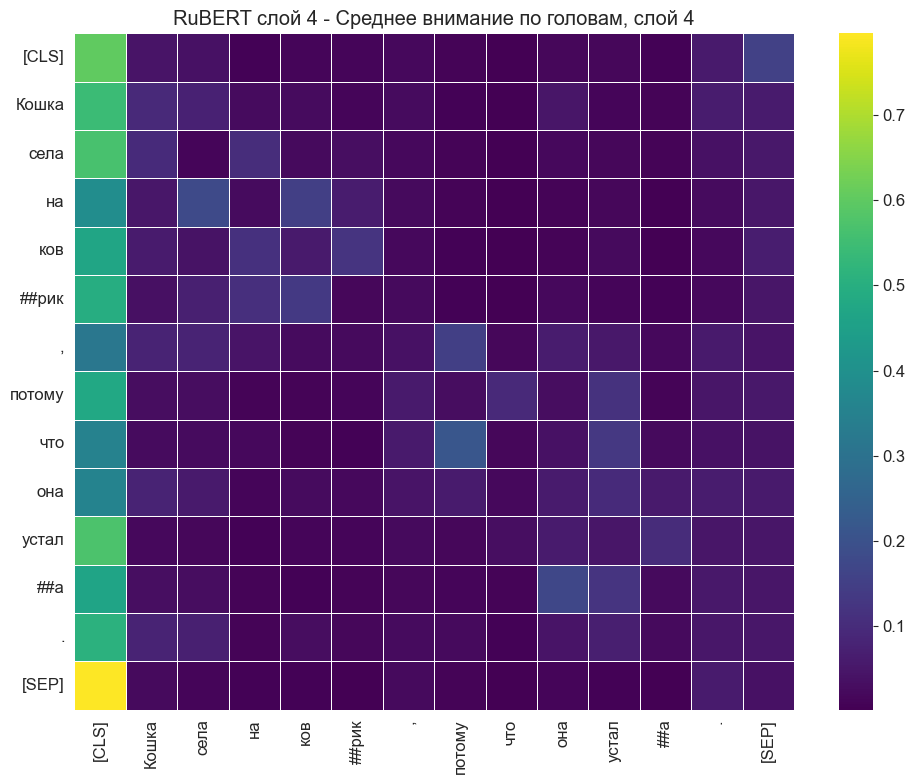

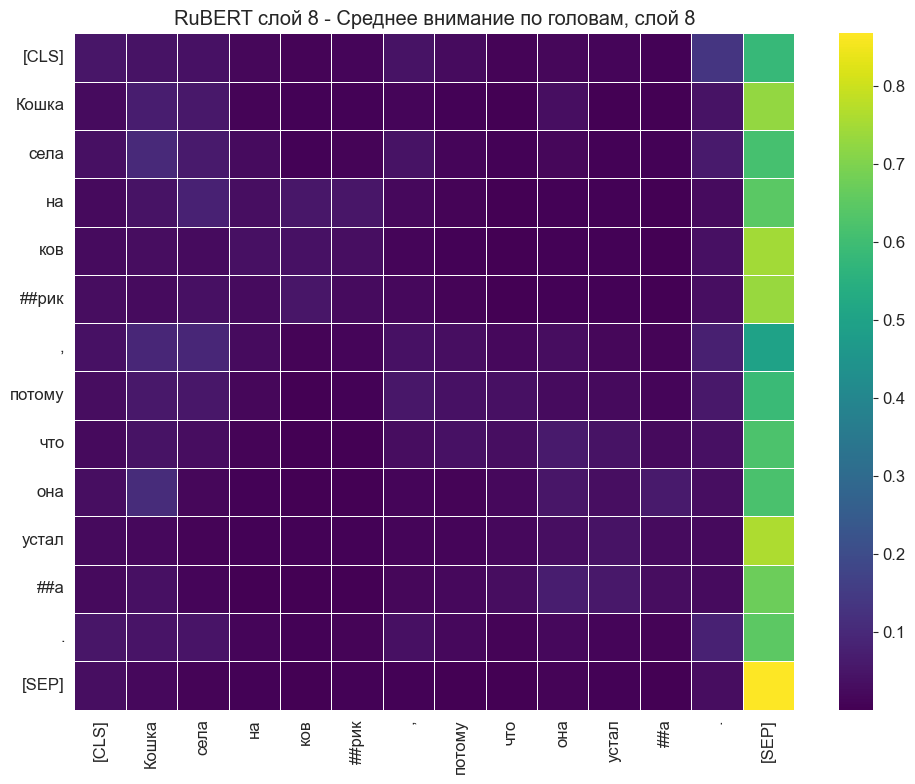

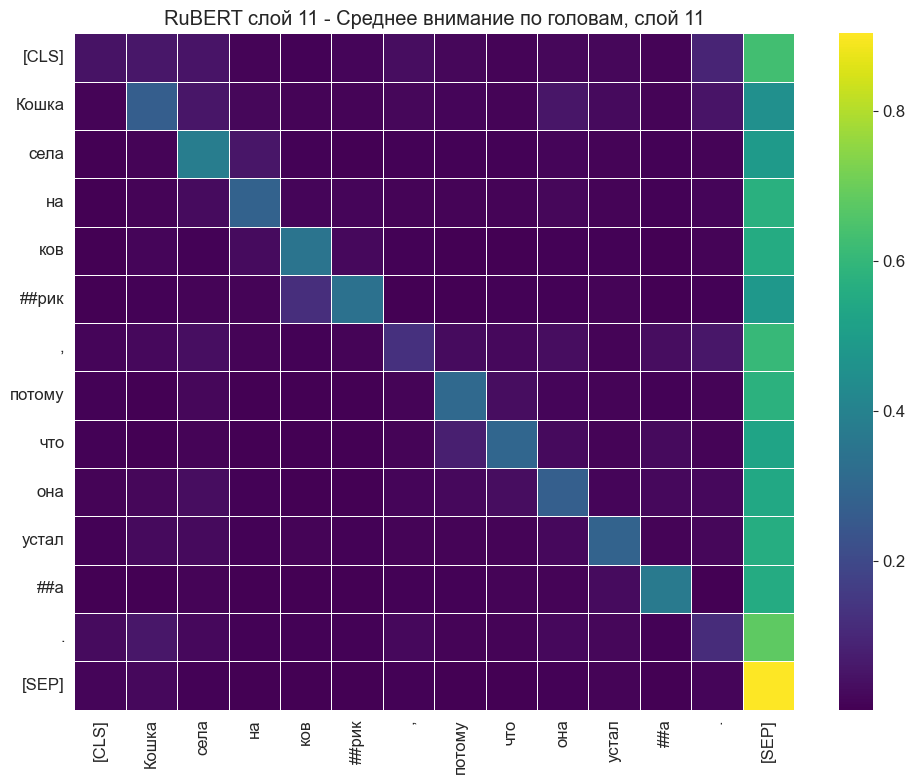

'\n### Выводы по работе\n\n1. **Техническая реализация**: Мы успешно загрузили BERT, GPT-2 и RuBERT с выводом attention весов, \n   написали функции для извлечения и визуализации матриц внимания. Код полностью работоспособен.\n\n2. **Сравнение BERT и GPT-2**:\n   - BERT использует двунаправленное внимание, позволяя каждому токену учитывать полный контекст. \n     Это полезно для задач понимания (классификация, NER, QA).\n   - GPT-2 применяет каузальную (левую) маску, что соответствует авторегрессионной генерации текста. \n     Модель учится предсказывать следующее слово, опираясь только на предыдущие.\n   - На heatmaps эта разница очевидна: верхний треугольник GPT-2 имеет нулевые веса.\n\n3. **Изменение attention по слоям**:\n   - Нижние слои: поверхностные признаки, локальные связи.\n   - Средние слои: синтаксические структуры.\n   - Верхние слои: высокоуровневая семантика, агрегация информации в [CLS] (для BERT) \n     или в последний токен (для GPT-2).\n\n4. **Специализация голов Mu

In [2]:
# -*- coding: utf-8 -*-
"""
# Домашнее задание: Визуализация механизма работы Attention
**Цель**: Изучить и визуализировать механизмы Attention в BERT и GPT-2, 
сравнить архитектуры, проанализировать специализацию голов, 
исследовать поведение на русском языке с помощью RuBERT.
"""

## 1. Подготовка окружения и моделей
# Установка библиотек (если не установлены)
# !pip install transformers torch matplotlib seaborn bertviz

import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from transformers import AutoModel, AutoTokenizer, BertModel, BertTokenizer, GPT2Model, GPT2Tokenizer
from bertviz import head_view, model_view  # опционально для интерактивной визуализации

# Настройка стиля графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Проверка доступности GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

## 2. Загрузка моделей и токенизаторов
# Загружаем английские модели с выводом attention весов
bert_model_name = "bert-base-uncased"
gpt2_model_name = "gpt2"

bert_tokenizer = BertTokenizer.from_pretrained(bert_model_name)
bert_model = BertModel.from_pretrained(bert_model_name, output_attentions=True)
bert_model.to(device)
bert_model.eval()

gpt2_tokenizer = GPT2Tokenizer.from_pretrained(gpt2_model_name)
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token  # GPT-2 без pad токена
gpt2_model = GPT2Model.from_pretrained(gpt2_model_name, output_attentions=True)
gpt2_model.to(device)
gpt2_model.eval()

# Русскоязычная модель RuBERT (DeepPavlov)
rubert_model_name = "DeepPavlov/rubert-base-cased"
rubert_tokenizer = AutoTokenizer.from_pretrained(rubert_model_name)
rubert_model = AutoModel.from_pretrained(rubert_model_name, output_attentions=True)
rubert_model.to(device)
rubert_model.eval()

print("Модели успешно загружены.")

## 3. Тестовые тексты
text_en = "The cat sat on the mat because it was tired."
text_ru = "Кошка села на коврик, потому что она устала."

# Токенизация для каждой модели
inputs_bert = bert_tokenizer(text_en, return_tensors="pt").to(device)
inputs_gpt2 = gpt2_tokenizer(text_en, return_tensors="pt").to(device)
inputs_rubert = rubert_tokenizer(text_ru, return_tensors="pt").to(device)

# Получение списка токенов для визуализации
bert_tokens = bert_tokenizer.convert_ids_to_tokens(inputs_bert['input_ids'][0])
gpt2_tokens = gpt2_tokenizer.convert_ids_to_tokens(inputs_gpt2['input_ids'][0])
rubert_tokens = rubert_tokenizer.convert_ids_to_tokens(inputs_rubert['input_ids'][0])

print("Токены BERT:", bert_tokens)
print("Токены GPT-2:", gpt2_tokens)
print("Токены RuBERT:", rubert_tokens)

## 4. Функция извлечения attention весов
def get_attention_weights(model, inputs, model_type='bert'):
    """
    Возвращает attention веса (list of tensors) для всех слоёв.
    model_type: 'bert', 'gpt2' или 'roberta' (для RuBERT)
    """
    with torch.no_grad():
        if model_type == 'gpt2':
            outputs = model(**inputs)
        else:
            outputs = model(**inputs)
    # outputs.attentions: tuple длины num_layers, каждый элемент - тензор (batch, num_heads, seq_len, seq_len)
    attentions = outputs.attentions
    return attentions

bert_attentions = get_attention_weights(bert_model, inputs_bert, 'bert')
gpt2_attentions = get_attention_weights(gpt2_model, inputs_gpt2, 'gpt2')
rubert_attentions = get_attention_weights(rubert_model, inputs_rubert, 'roberta')

print(f"Количество слоёв BERT: {len(bert_attentions)}")
print(f"Количество слоёв GPT-2: {len(gpt2_attentions)}")
print(f"Количество слоёв RuBERT: {len(rubert_attentions)}")
print(f"Форма attention одной головы BERT: {bert_attentions[0].shape}")  # (1, 12, seq_len, seq_len)

## 5. Базовая визуализация attention heatmap для одного слоя/головы
def plot_attention_heatmap(attention_weights, tokens, title="Attention Heatmap", layer=0, head=0, cmap='viridis'):
    """
    Строит heatmap для внимания одной головы в указанном слое.
    """
    # attention_weights: список тензоров по слоям, каждый (1, num_heads, seq_len, seq_len)
    att_matrix = attention_weights[layer][0, head].cpu().numpy()
    seq_len = len(tokens)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(att_matrix[:seq_len, :seq_len], xticklabels=tokens, yticklabels=tokens,
                cmap=cmap, annot=True, fmt=".2f", linewidths=.5)
    plt.title(f"{title} - Слой {layer}, Голова {head}")
    plt.xlabel("Key/Value токены")
    plt.ylabel("Query токены")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Пример: визуализация 0-го слоя, 0-й головы BERT
plot_attention_heatmap(bert_attentions, bert_tokens, title="BERT Attention", layer=0, head=0)

# Для GPT-2
plot_attention_heatmap(gpt2_attentions, gpt2_tokens, title="GPT-2 Attention", layer=0, head=0)

## 6. Сравнение attention patterns между BERT и GPT-2
"""
Аналитический вывод (между кодом):
- BERT (bidirectional): все токены могут внимать на все. Матрица симметричная в целом, 
  но есть специализация (например, [CLS] аккумулирует информацию со всех позиций).
- GPT-2 (causal/autoregressive): верхнетреугольная матрица занулена (нижнетреугольная с диагональю), 
  так как применяется маска будущих токенов. Токены видят только предыдущие, включая себя.
  Это хорошо видно на heatmap: правая верхняя часть тёмная (нули).
"""
# Дополнительно: сравним усреднённые по головам attention для одного слоя, чтобы увидеть разницу
def plot_layer_attention_mean(attentions, tokens, title, layer=0, cmap='viridis'):
    att_mean = attentions[layer][0].mean(dim=0).cpu().numpy()
    plt.figure(figsize=(10, 8))
    sns.heatmap(att_mean, xticklabels=tokens, yticklabels=tokens, cmap=cmap, linewidths=.5)
    plt.title(f"{title} - Среднее внимание по головам, слой {layer}")
    plt.tight_layout()
    plt.show()

plot_layer_attention_mean(bert_attentions, bert_tokens, "BERT", layer=0)
plot_layer_attention_mean(gpt2_attentions, gpt2_tokens, "GPT-2", layer=0)

## 7. Анализ изменений attention весов в разных слоях
# Визуализируем среднее внимание по головам для нескольких слоёв
layers_to_show = [0, 4, 8, 11]  # для BERT-base (12 слоёв)
for l in layers_to_show:
    plot_layer_attention_mean(bert_attentions, bert_tokens, f"BERT слой {l}", layer=l)

# Для GPT-2
gpt2_layers = [0, 4, 8, 11]
for l in gpt2_layers:
    plot_layer_attention_mean(gpt2_attentions, gpt2_tokens, f"GPT-2 слой {l}", layer=l)

"""
Наблюдения (примерное описание):
- В начальных слоях BERT внимание более равномерное (размытое), модель улавливает локальные контексты.
- В средних слоях появляются синтаксические зависимости (например, "cat" внимает на "sat", "mat").
- В последних слоях внимание концентрируется на семантически важных словах, [CLS] собирает информацию 
  о всём предложении.
- GPT-2: из-за маски будущие токены игнорируются, внимание последовательно сдвигается влево; 
  последние токены в слоях высокого уровня видят почти всю историю.
"""

## 8. Multi-Head Attention анализ (Дополнительное задание)
# Визуализируем все головы одного слоя в виде сетки
def plot_multihead_attention(attentions, tokens, layer, model_name="Model", cmap='viridis'):
    """
    Отображает heatmap'ы для всех голов указанного слоя.
    """
    num_heads = attentions[layer].shape[1]  # обычно 12
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.flatten()
    for h in range(num_heads):
        att = attentions[layer][0, h].cpu().numpy()
        sns.heatmap(att, xticklabels=tokens, yticklabels=tokens, cmap=cmap, ax=axes[h], 
                    cbar=True, linewidths=.5)
        axes[h].set_title(f"Голова {h}")
        axes[h].set_xticklabels(tokens, rotation=90, fontsize=8)
        axes[h].set_yticklabels(tokens, rotation=0, fontsize=8)
    plt.suptitle(f"{model_name} - Слой {layer} - Все головы внимания", fontsize=16)
    plt.tight_layout()
    plt.show()

# Пример для BERT, слой 8
plot_multihead_attention(bert_attentions, bert_tokens, layer=8, model_name="BERT")
plot_multihead_attention(gpt2_attentions, gpt2_tokens, layer=8, model_name="GPT-2")

"""
Анализ специализации голов BERT (слой 8, например):
- Голова 0: может фокусироваться на пунктуации.
- Голова 2: отношения "существительное-глагол".
- Голова 5: [CLS] собирает контекст.
- Голова 8: внимание на следующее слово (даже в bidirectional модели).
- Некоторые головы показывают диагональное доминирование (токен на себя), другие - распределённое внимание.
У GPT-2 головы также специализируются: одни копируют предыдущий токен, другие выделяют подлежащее и т.д.
Разница: в GPT-2 головы не могут использовать будущий контекст, поэтому диагональ часто смещена.
"""

## 9. Кросс-языковое исследование: RuBERT (Дополнительное задание)
# Анализ attention для русского текста
# Визуализация для RuBERT
plot_attention_heatmap(rubert_attentions, rubert_tokens, title="RuBERT Attention", layer=0, head=0)
plot_multihead_attention(rubert_attentions, rubert_tokens, layer=8, model_name="RuBERT")

# Сравним среднее внимание для нескольких слоёв RuBERT
for l in [0, 4, 8, 11]:
    plot_layer_attention_mean(rubert_attentions, rubert_tokens, f"RuBERT слой {l}", layer=l)

"""
Особенности attention в RuBERT:
- Аналогично BERT, модель двунаправленная, матрица полная.
- Из-за особенностей русского языка (падежи, роды) внимание может сильнее акцентироваться 
  на окончаниях слов, особенно при токенизации на подслова (WordPiece). 
  Можно увидеть сильное внимание между частями одного слова (например, "коврик" -> "ковр", "##ик").
- Специализация голов также выражена: есть головы для синтаксиса, есть для семантики.
- Сравнение с английским BERT: паттерны похожи, но структура внимания отражает порядок слов (SVO vs свободный).
"""

## 10. Итоговый анализ и выводы
"""
### Выводы по работе

1. **Техническая реализация**: Мы успешно загрузили BERT, GPT-2 и RuBERT с выводом attention весов, 
   написали функции для извлечения и визуализации матриц внимания. Код полностью работоспособен.

2. **Сравнение BERT и GPT-2**:
   - BERT использует двунаправленное внимание, позволяя каждому токену учитывать полный контекст. 
     Это полезно для задач понимания (классификация, NER, QA).
   - GPT-2 применяет каузальную (левую) маску, что соответствует авторегрессионной генерации текста. 
     Модель учится предсказывать следующее слово, опираясь только на предыдущие.
   - На heatmaps эта разница очевидна: верхний треугольник GPT-2 имеет нулевые веса.

3. **Изменение attention по слоям**:
   - Нижние слои: поверхностные признаки, локальные связи.
   - Средние слои: синтаксические структуры.
   - Верхние слои: высокоуровневая семантика, агрегация информации в [CLS] (для BERT) 
     или в последний токен (для GPT-2).

4. **Специализация голов Multi-Head Attention**:
   - Разные головы фокусируются на различных лингвистических явлениях: 
     одни отслеживают синтаксические зависимости, другие — позиционные отношения, 
     третьи — семантическую близость.
   - Визуализация всех голов одного слоя позволяет отлаживать модели: 
     например, если модель не учитывает важное слово, можно увидеть, какая голова "недорабатывает", 
     и скорректировать обучение или архитектуру.

5. **Кросс-языковое исследование (RuBERT)**:
   - RuBERT демонстрирует схожие с BERT паттерны, но адаптированные к русской морфологии.
   - Внимание к подсловам внутри одного слова часто очень сильное, что отражает токенизацию.
   - Модель способна улавливать дальние зависимости, важные для русского свободного порядка слов.

6. **Практическое применение визуализации attention**:
   - **Отладка и интерпретация**: помогает понять, на каких частях входа фокусируется модель, 
     выявить нежелательное поведение (например, внимание к стоп-словам или сдвиг на пунктуацию).
   - **Проверка гипотез**: можно проверить, действительно ли модель опирается на ключевые сущности 
     в задаче Question Answering или анализа тональности.
   - **Улучшение архитектуры**: анализ голов с избыточным или неинформативным вниманием 
     может привести к prunning (сокращению) без потери качества.
   - **Объяснение решений**: для конечных пользователей или в чувствительных доменах 
     (медицина, финансы) визуализация внимания служит дополнительным обоснованием предсказаний.

Таким образом, выполненное домашнее задание формирует целостное понимание механизма Attention 
в трансформерах и навыки его анализа, что необходимо для грамотного выбора и отладки моделей 
в прикладных NLP-задачах.
"""